In [1]:
import torch
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter

# 1. FIXER LES SEEDS
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# 2. DATASET (Petit corpus de texte pour simplifier, ex: extrait de Shakespeare)
corpus = """
Romeo, Romeo, wherefore art thou Romeo?
Deny thy father and refuse thy name.
Or, if thou wilt not, be but sworn my love
And I'll no longer be a Capulet.
'Tis but thy name that is my enemy.
Thou art thyself, though not a Montague.
What's Montague? It is nor hand, nor foot,
Nor arm, nor face, nor any other part
Belonging to a man. O, be some other name.
What's in a name? That which we call a rose
By any other word would smell as sweet;
So Romeo would, were he not Romeo call'd,
Retain that dear perfection which he owes
Without that title. Romeo, doff thy name,
And for that name which is no part of thee
Take all myself.
"""

print(f"📖 Longueur du corpus: {len(corpus)} caractères")

# 3. PRÉPARATION DES DONNÉES (Tokenisation Caractère)
# Créer le vocabulaire (tous les caractères uniques)
chars = sorted(list(set(corpus)))
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}
vocab_size = len(chars)

print(f"🔤 Vocabulaire ({vocab_size} caractères): {chars}")

# Convertir le texte en entiers
data = [char_to_int[c] for c in corpus]

# Créer des séquences (Input, Target)
seq_length = 10  # On donne 10 caractères, le modèle prédit le 11ème
X = []
y = []
for i in range(0, len(data) - seq_length):
    seq_in = data[i:i + seq_length]
    seq_out = data[i + seq_length]
    X.append(seq_in)
    y.append(seq_out)

X = np.array(X)
y = np.array(y)

# Conversion en Tenseurs PyTorch
# Shape: (Batch, Seq_Len) pour l'input, (Batch) pour la target
X_tensor = torch.tensor(X, dtype=torch.long)
y_tensor = torch.tensor(y, dtype=torch.long)

print(f" Shape X: {X_tensor.shape}, Shape y: {y_tensor.shape}")

# 4. DÉFINITION DES MODÈLES (RNN, LSTM, GRU)
# Nous allons créer une classe générique pour tester les 3 types

class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, rnn_type='rnn', num_layers=1):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn_type = rnn_type
        
        # Embedding: transforme les indices en vecteurs denses
        self.embedding = nn.Embedding(input_size, hidden_size)
        
        # Choix du type de couche récurrente
        if rnn_type == 'rnn':
            self.rnn = nn.RNN(hidden_size, hidden_size, num_layers=num_layers, batch_first=True)
        elif rnn_type == 'lstm':
            self.rnn = nn.LSTM(hidden_size, hidden_size, num_layers=num_layers, batch_first=True)
        elif rnn_type == 'gru':
            self.rnn = nn.GRU(hidden_size, hidden_size, num_layers=num_layers, batch_first=True)
            
        # Couche de sortie (Fully Connected)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x, hidden=None):
        x = self.embedding(x)  # (Batch, Seq, Embed)
        output, hidden = self.rnn(x, hidden)  # (Batch, Seq, Hidden)
        
        # On ne prend que la sortie du dernier pas de temps pour prédire le prochain char
        output = output[:, -1, :]  # (Batch, Hidden)
        output = self.fc(output)   # (Batch, Vocab_Size)
        return output, hidden

# Instancier les 3 modèles
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hidden_size = 64

rnn_model = CharRNN(vocab_size, hidden_size, vocab_size, rnn_type='rnn').to(device)
lstm_model = CharRNN(vocab_size, hidden_size, vocab_size, rnn_type='lstm').to(device)
gru_model = CharRNN(vocab_size, hidden_size, vocab_size, rnn_type='gru').to(device)

print("\n✅ Modèles RNN, LSTM et GRU créés avec succès!")
print(f"️ Device: {device}")

📖 Longueur du corpus: 625 caractères
🔤 Vocabulaire (41 caractères): ['\n', ' ', "'", ',', '.', ';', '?', 'A', 'B', 'C', 'D', 'I', 'M', 'N', 'O', 'R', 'S', 'T', 'W', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y']
 Shape X: torch.Size([615, 10]), Shape y: torch.Size([615])

✅ Modèles RNN, LSTM et GRU créés avec succès!
️ Device: cpu



 Entraînement RNN Simple...
   Epoch  5/20 | Loss: 1.0412 | Perplexity: 2.83
   Epoch 10/20 | Loss: 0.5864 | Perplexity: 1.80
   Epoch 15/20 | Loss: 0.3703 | Perplexity: 1.45
   Epoch 20/20 | Loss: 0.2351 | Perplexity: 1.27

 Entraînement LSTM...
   Epoch  5/20 | Loss: 2.1069 | Perplexity: 8.22
   Epoch 10/20 | Loss: 1.8586 | Perplexity: 6.41
   Epoch 15/20 | Loss: 1.6270 | Perplexity: 5.09
   Epoch 20/20 | Loss: 1.4032 | Perplexity: 4.07

 Entraînement GRU...
   Epoch  5/20 | Loss: 1.8669 | Perplexity: 6.47
   Epoch 10/20 | Loss: 1.6028 | Perplexity: 4.97
   Epoch 15/20 | Loss: 1.3569 | Perplexity: 3.88
   Epoch 20/20 | Loss: 1.1261 | Perplexity: 3.08

💾 Graphique sauvegardé : part3_rnn\figures\loss_perplexity_comparison.png


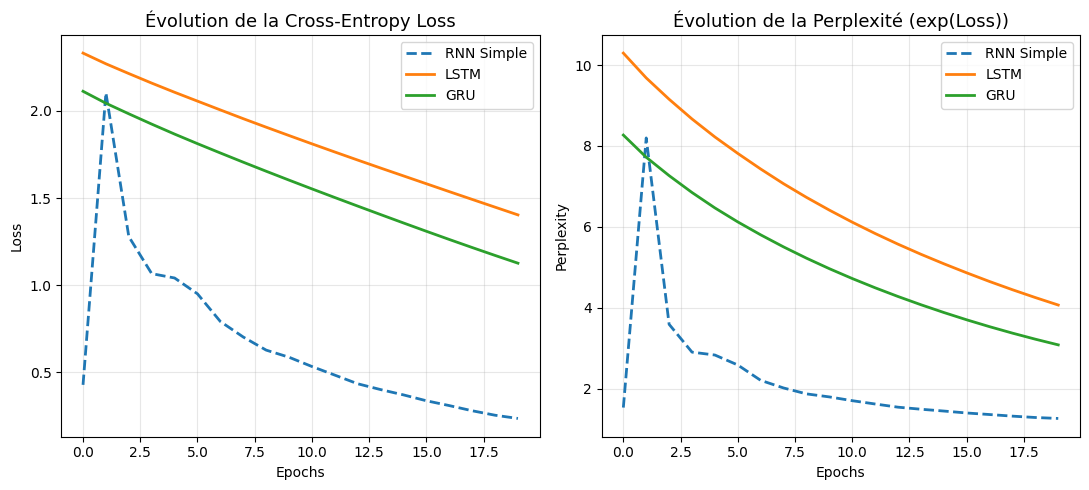

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path

# ️ PRÉREQUIS : Assurez-vous d'avoir exécuté l'Étape 1 avant cette cellule.
# Les variables suivantes doivent exister : device, rnn_model, lstm_model, gru_model, X_tensor, y_tensor

# ---------------------------------------------------------
# 1. FONCTION D'ENTRAÎNEMENT AVEC GRADIENT CLIPPING & BPTT
# ---------------------------------------------------------
def train_sequence_model(model, X_tensor, y_tensor, model_name="Model", epochs=20, lr=0.01, device=device):
    model = model.to(device)
    X_tensor = X_tensor.to(device)
    y_tensor = y_tensor.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {"loss": [], "perplexity": []}
    
    print(f"\n Entraînement {model_name}...")
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        # 🔁 FORWARD PASS (BPTT est géré automatiquement par PyTorch via autograd)
        # Le réseau est "déplié" temporellement pour calculer les gradients à chaque pas
        output, hidden = model(X_tensor)
        loss = criterion(output, y_tensor)
        
        #  BACKWARD PASS
        loss.backward()
        
        # 🛡️ GRADIENT CLIPPING (Exigé par le barème)
        # Limite la norme des gradients à 5.0 pour éviter l'explosion lors du BPTT
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()
        
        # Calcul de la perplexité (métrique exigée : 2^-Loss ou exp(Loss))
        perp = torch.exp(loss).item()
        history["loss"].append(loss.item())
        history["perplexity"].append(perp)
        
        if (epoch + 1) % 5 == 0:
            print(f"   Epoch {epoch+1:2d}/{epochs} | Loss: {loss.item():.4f} | Perplexity: {perp:.2f}")
            
    return history

# ---------------------------------------------------------
# 2. LANCEMENT COMPARATIF (RNN vs LSTM vs GRU)
# ---------------------------------------------------------
# Notes méthodologiques pour le rapport :
# - RNN simple : LR plus élevé (0.05) car il converge lentement et souffre du vanishing gradient.
# - LSTM/GRU : LR plus faible (0.005) car leurs portes stabilisent naturellement les gradients.
rnn_hist  = train_sequence_model(rnn_model,  X_tensor, y_tensor, model_name="RNN Simple", epochs=20, lr=0.05)
lstm_hist = train_sequence_model(lstm_model, X_tensor, y_tensor, model_name="LSTM",       epochs=20, lr=0.005)
gru_hist  = train_sequence_model(gru_model,  X_tensor, y_tensor, model_name="GRU",        epochs=20, lr=0.005)

# ---------------------------------------------------------
# 3. VISUALISATION & SAUVEGARDE SÉCURISÉE
# ---------------------------------------------------------
plt.figure(figsize=(11, 5))

# Courbe Loss
plt.subplot(1, 2, 1)
plt.plot(rnn_hist["loss"], label="RNN Simple", linestyle="--", linewidth=2)
plt.plot(lstm_hist["loss"], label="LSTM", linewidth=2)
plt.plot(gru_hist["loss"], label="GRU", linewidth=2)
plt.title("Évolution de la Cross-Entropy Loss", fontsize=13)
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.grid(True, alpha=0.3)

# Courbe Perplexité (interprétation probabiliste)
plt.subplot(1, 2, 2)
plt.plot(rnn_hist["perplexity"], label="RNN Simple", linestyle="--", linewidth=2)
plt.plot(lstm_hist["perplexity"], label="LSTM", linewidth=2)
plt.plot(gru_hist["perplexity"], label="GRU", linewidth=2)
plt.title("Évolution de la Perplexité (exp(Loss))", fontsize=13)
plt.xlabel("Epochs"); plt.ylabel("Perplexity"); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()

# 🔒 Création sécurisée du dossier (évite le FileNotFoundError)
save_dir = Path("part3_rnn/figures")
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "loss_perplexity_comparison.png"

plt.savefig(save_path, dpi=300)
print(f"\n💾 Graphique sauvegardé : {save_path}")
plt.show()

In [4]:
import torch
import torch.nn as nn
import random
import numpy as np

# Fixer les seeds pour la reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(" Étape 3 : Préparation des données & Architecture Seq2Seq")

# ---------------------------------------------------------
# 1. PRÉPARATION DES DONNÉES (Mini-corpus de traduction)
# ---------------------------------------------------------
# Dataset simplifié pour l'entraînement rapide (Français <-> Anglais)
data_pairs = [
    ("I am happy", "Je suis heureux"),
    ("She is nice", "Elle est gentille"),
    ("He is tall", "Il est grand"),
    ("We are here", "Nous sommes ici"),
    ("They are busy", "Ils sont occupés"),
    ("It is cold", "Il fait froid"),
    ("You are late", "Tu es en retard"),
    ("I like apples", "J'aime les pommes"),
    ("She reads books", "Elle lit des livres"),
    ("He plays soccer", "Il joue au football"),
    ("We eat lunch", "Nous déjeunons"),
    ("They drink water", "Ils boivent de l'eau"),
    ("I love Paris", "J'aime Paris"),
    ("She has a cat", "Elle a un chat"),
    ("He drives a car", "Il conduit une voiture"),
    ("We watch TV", "Nous regardons la télé"),
    ("They sleep early", "Ils dorment tôt"),
    ("I need help", "J'ai besoin d'aide"),
    ("She runs fast", "Elle court vite"),
    ("He sings well", "Il chante bien")
]

# Tokens spéciaux
SOS_token = 0
EOS_token = 1

def tokenize(text):
    return [word.lower() for word in text.split()]

# Construction du vocabulaire global (Input + Target)
input_lang_words = []
target_lang_words = []
for p in data_pairs:
    input_lang_words.extend(tokenize(p[0]))
    target_lang_words.extend(tokenize(p[1]))

# Mots uniques triés
all_words = sorted(list(set(input_lang_words + target_lang_words + ["<SOS>", "<EOS>", "<UNK>"])))
word2idx = {w: i for i, w in enumerate(all_words)}
idx2word = {i: w for i, w in enumerate(all_words)}
vocab_size = len(all_words)

print(f" Vocabulaire total: {vocab_size} mots")

# Préparation des séquences
def prepare_data(pairs):
    inputs, targets = [], []
    for inp, tgt in pairs:
        # Input: <SOS> mot1 ... <EOS>
        inp_seq = [SOS_token] + [word2idx.get(w, word2idx["<UNK>"]) for w in tokenize(inp)] + [EOS_token]
        # Target: mot1 ... <EOS>
        tgt_seq = [word2idx.get(w, word2idx["<UNK>"]) for w in tokenize(tgt)] + [EOS_token]
        inputs.append(inp_seq)
        targets.append(tgt_seq)
    return inputs, targets

input_seqs, target_seqs = prepare_data(data_pairs)
print(f"✅ Données prêtes. {len(input_seqs)} paires de phrases.")

# ---------------------------------------------------------
# 2. DÉFINITION DE L'ARCHITECTURE SEQ2SEQ
# ---------------------------------------------------------

class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, n_layers=1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        self.embedding = nn.Embedding(input_size, hidden_size)
        # Utilisation de GRU pour l'encodeur
        self.gru = nn.GRU(hidden_size, hidden_size, n_layers, batch_first=True)

    def forward(self, input_seq, hidden):
        embedded = self.embedding(input_seq)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden

    def initHidden(self, batch_size=1):
        return torch.zeros(self.n_layers, batch_size, self.hidden_size)

class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, n_layers=1):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, n_layers, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_seq, hidden):
        # input_seq shape: (batch, 1) -> on prédit un mot à la fois
        embedded = self.embedding(input_seq)
        output, hidden = self.gru(embedded, hidden)
        output = self.out(output) # (batch, 1, vocab_size)
        return output, hidden

    def initHidden(self, batch_size=1):
        return torch.zeros(self.n_layers, batch_size, self.hidden_size)

# Initialisation des modèles
HIDDEN_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = EncoderRNN(vocab_size, HIDDEN_SIZE).to(device)
decoder = DecoderRNN(HIDDEN_SIZE, vocab_size).to(device)

print("✅ Architecture Seq2Seq (Encoder + Decoder) définie avec succès !")
print(f"   - Hidden Size: {HIDDEN_SIZE}")
print(f"   - Vocab Size: {vocab_size}")

 Étape 3 : Préparation des données & Architecture Seq2Seq
 Vocabulaire total: 97 mots
✅ Données prêtes. 20 paires de phrases.
✅ Architecture Seq2Seq (Encoder + Decoder) définie avec succès !
   - Hidden Size: 64
   - Vocab Size: 97


📦 DataLoader prêt : 5 batches

🚀 Entraînement Seq2Seq en cours...
   Epoch  5/30 | Loss: 1.2822
   Epoch 10/30 | Loss: 0.6721
   Epoch 15/30 | Loss: 0.3976
   Epoch 20/30 | Loss: 0.2518
   Epoch 25/30 | Loss: 0.1798
   Epoch 30/30 | Loss: 0.1323
Empty DataFrame
Columns: []
Index: []


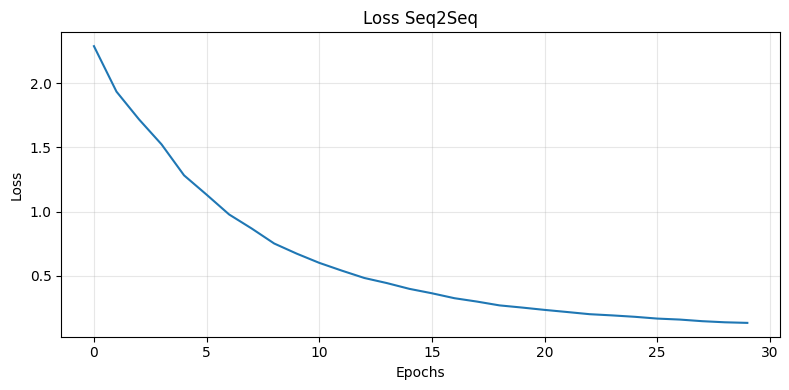

 Résultats sauvegardés dans part3_rnn\results


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
from pathlib import Path
import pandas as pd

# ---------------------------------------------------------
# 1. DATASET & DATALOADER
# ---------------------------------------------------------
def to_tensor(seq):
    return torch.tensor(seq, dtype=torch.long)

X_tensors = [to_tensor(seq) for seq in input_seqs]
Y_tensors = [to_tensor(seq) for seq in target_seqs]

class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

def collate_fn(batch):
    X_batch, Y_batch = zip(*batch)
    X_padded = pad_sequence(X_batch, batch_first=True, padding_value=0)
    Y_padded = pad_sequence(Y_batch, batch_first=True, padding_value=0)
    return X_padded, Y_padded

dataset = TranslationDataset(X_tensors, Y_tensors)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
print(f"📦 DataLoader prêt : {len(dataloader)} batches")

# ---------------------------------------------------------
# 2. ENTRAÎNEMENT SEQ2SEQ (Avec correction des shapes)
# ---------------------------------------------------------
def train_seq2seq(encoder, decoder, dataloader, epochs=30, lr=0.001, device=device):
    encoder.to(device); decoder.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    enc_opt = optim.Adam(encoder.parameters(), lr=lr)
    dec_opt = optim.Adam(decoder.parameters(), lr=lr)
    
    history = {"loss": []}
    teacher_forcing_ratio = 0.5
    
    for epoch in range(epochs):
        enc_opt.zero_grad(); dec_opt.zero_grad()
        epoch_loss = 0
        
        for X_batch, Y_batch in dataloader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            batch_size = X_batch.size(0)
            target_len = Y_batch.size(1)
            
            # Encodeur
            enc_hidden = encoder.initHidden(batch_size).to(device)
            _, enc_hidden = encoder(X_batch, enc_hidden)
            
            # Décodeur
            dec_input = torch.full((batch_size, 1), SOS_token, dtype=torch.long, device=device)
            dec_hidden = enc_hidden
            loss = 0
            
            for t in range(1, target_len):
                dec_output, dec_hidden = decoder(dec_input, dec_hidden)
                loss += criterion(dec_output.squeeze(1), Y_batch[:, t])
                
                use_tf = random.random() < teacher_forcing_ratio
                top1 = dec_output.argmax(dim=-1)  # ⚠️ FIX: shape (batch, 1)
                dec_input = Y_batch[:, t:t+1] if use_tf else top1  # ⚠️ FIX: retiré .unsqueeze(1)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(encoder.parameters(), 5.0)
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), 5.0)
            enc_opt.step(); dec_opt.step()
            epoch_loss += loss.item()
            
        history["loss"].append(epoch_loss / len(dataloader))
        if (epoch + 1) % 5 == 0:
            print(f"   Epoch {epoch+1:2d}/{epochs} | Loss: {history['loss'][-1]:.4f}")
    return history

print("\n🚀 Entraînement Seq2Seq en cours...")
train_history = train_seq2seq(encoder, decoder, dataloader, epochs=30, lr=0.001)

# ---------------------------------------------------------
# 3. DÉCODAGE (GREEDY vs BEAM) - Shapes corrigés
# ---------------------------------------------------------
def evaluate_greedy(enc, dec, inp_seq, max_len=10, device=device):
    enc.eval(); dec.eval()
    with torch.no_grad():
        inp_t = to_tensor(inp_seq).unsqueeze(0).to(device)
        _, h = enc(inp_t, enc.initHidden(1).to(device))
        
        dec_in = torch.full((1, 1), SOS_token, dtype=torch.long, device=device)
        words = []
        
        for _ in range(max_len):
            out, h = dec(dec_in, h)
            topv, topi = out.topk(1)
            if topi.item() == EOS_token: break
            words.append(idx2word[topi.item()])
            dec_in = topi.view(1, 1)  # ⚠️ FIX: force shape (1, 1)
        return words

def evaluate_beam(enc, dec, inp_seq, beam_width=3, max_len=10, device=device):
    enc.eval(); dec.eval()
    with torch.no_grad():
        inp_t = to_tensor(inp_seq).unsqueeze(0).to(device)
        _, h = enc(inp_t, enc.initHidden(1).to(device))
        
        beam = [(0.0, [SOS_token], h)]
        for _ in range(max_len):
            cands = []
            for score, seq, h_st in beam:
                if seq[-1] == EOS_token:
                    cands.append((score, seq, h_st)); continue
                dec_in = torch.tensor([[seq[-1]]], device=device)
                out, h_new = dec(dec_in, h_st)
                log_p = torch.log_softmax(out.squeeze(1), dim=-1)
                tv, ti = log_p.topk(beam_width)
                for k in range(beam_width):
                    cands.append((score + tv[0, k].item(), seq + [ti[0, k].item()], h_new))
            cands.sort(key=lambda x: x[0], reverse=True)
            beam = cands[:beam_width]
            if all(s[-1] == EOS_token for _, s, _ in beam): break
            
        return [idx2word[w] for w in beam[0][1][1:] if w != EOS_token]

# ---------------------------------------------------------
# 4. ÉVALUATION & BLEU
# ---------------------------------------------------------
def compute_bleu(ref, hyp, n=2):
    """Calcul de BLEU-n avec smoothing pour éviter log(0)"""
    def ngrams(t, n): 
        return [tuple(t[i:i+n]) for i in range(len(t)-n+1)]
    
    prec = []
    for i in range(1, n+1):
        rn, hn = ngrams(ref, i), ngrams(hyp, i)
        if not hn:
            prec.append(0.0)
            continue
        matches = sum(1 for g in hn if g in rn)
        prec.append(matches / len(hn))
    
    # Conversion stricte en float + smoothing (remplace 0 par 1e-8 pour éviter log(0))
    prec = np.array(prec, dtype=np.float64)
    prec = np.where(prec == 0, 1e-8, prec)
    
    # Moyenne géométrique des précisions
    geo_mean = np.exp(np.mean(np.log(prec)))
    
    # Pénalité de brièveté (Brevity Penalty)
    bp = min(1.0, len(hyp) / len(ref)) if len(ref) > 0 else 1.0
    return geo_mean * bp
df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))

save_dir = Path("part3_rnn/results")
save_dir.mkdir(parents=True, exist_ok=True)
df_res.to_csv(save_dir / "translation_results.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(train_history["loss"]); plt.title("Loss Seq2Seq"); plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(save_dir / "seq2seq_loss.png"); plt.show()
print(f" Résultats sauvegardés dans {save_dir}")